# Quick Start: Circular Diffusion Model

This tutorial demonstrates how to simulate data from a **Circular Diffusion Model (CDM)** and recover model parameters using likelihood-based estimation with JEAM. 

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/AmirHoseinHadian/JEAM/blob/main/docs/notebooks/01_Quick_Start.ipynb)

[View the notebook on GitHub](https://github.com/AmirHoseinHadian/JEAM/blob/main/docs/notebooks/01_Quick_Start.ipynb)

In [1]:
import importlib.util
import subprocess
import sys

if importlib.util.find_spec("jeam") is None:
    subprocess.check_call(
        [sys.executable, 
         "-m", 
         "pip", 
         "install", 
         "--quiet", 
         "git+https://github.com/AmirHoseinHadian/JEAM.git@main"]
    )

## 1. Import required packages

In [2]:
import numpy as np              # Numerical computations
import pandas as pd             # Data handling

# Visualization
import seaborn as sns
import matplotlib.pyplot as plt

# Optimization
from scipy.optimize import differential_evolution

# JEAM model
from jeam.Models.Circular import CircularDiffusionModel as CDM

## 2. Create a circular diffusion model


To instantiate a model, create an object of the `CircularDiffusionModel` class and specify the threshold dynamics.

The `threshold_dynamic` argument determines whether the decision boundary radius changes over time.

Available options:

- `'fixed'` (default)
- `'linear'`
- `'exponential'`
- `'hyperbolic'`
- `'custom'`

In [3]:
model = CDM(threshold_dynamic='fixed')

The model instance provides two key methods:

-  `simulate(...)`, which simulates data (response times and response angles) from the model for a given parameters.
- `joint_lpdf(...)`, which calculates the joint log-likelihood of the model for the given data and set of parameters.

## 3. Simulate continuous-response decision data

In [4]:
# Ground-truth parameters
threshold = 2.0                    # Decision threshold
drift_vector = np.array([2.0, 0.0]) # Drift in x and y directions
ndt = 0.25                         # Non-decision time

# Simulate data
sim_data = model.simulate(
    drift_vector,
    ndt,
    threshold,
    n_sample=1000
)

sim_data.head()

,rt,response
0,0.730,0.775290
1,0.443,0.083287
2,0.701,0.156800
3,1.189,0.750497
4,2.244,0.079751


The simulated dataset contains:
- `rt`: response times
- `response`: continuous angular responses on the circle in radian

## 4. Visualizing simulated data

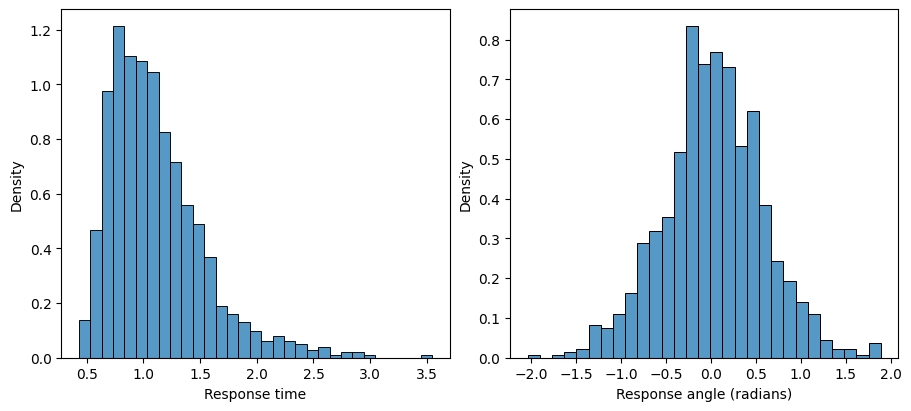

In [5]:
plt.figure(figsize=(9, 4), layout='constrained')

plt.subplot(121)
sns.histplot(sim_data['rt'], stat='density')
plt.xlabel("Response time")

plt.subplot(122)
sns.histplot(sim_data['response'], stat='density')
plt.xlabel("Response angle (radians)");

## 5. Define the likelihood function

We estimate parameters by **maximizing the joint likelihood** of response times and continuous response angles.

In [6]:
def negative_log_likelihood(prms, rt, theta, model):
    threshold =  prms[0] 
    ndt = prms[1] 
    drift_vec = np.array([prms[2], prms[3]])
    
    logpdf = model.joint_lpdf(rt, theta, drift_vec, ndt, threshold)
    
    return -np.sum(logpdf)

## 6. Estimate parameters using differential evolution

After defining the `negative_log_likelihood` function, users can pass this function to any optimization routine. For instance, users can use `scipy.optimize.differential_evolution`. This optimizer requires the parameters' range. In other words, `differential_evolution` searches for the global minimum of the function within a **bounded space** defined by the user. Therefore, if users wish to employ `differential_evolution` as the optimizer, providing the parameter bounds is essential. 

!!! warning "Parameter order must match bounds" 

    The order of parameters in bounds must exactly match the order in which parameters are unpacked inside the `negative_log_likelihood function`. **A mismatch will lead to incorrect estimation.**
      

In [7]:
# Parameter bounds
bounds = [
    (0.05, 5.0),   # threshold
    (0.0, 2.0),    # non-decision time
    (-5.0, 5.0),   # drift_x
    (-5.0, 5.0),   # drift_y
]

param_names = ["threshold", "ndt", "drift_x", "drift_y"]


result = differential_evolution(
    negative_log_likelihood,
    bounds=bounds,
    args=(
        sim_data["rt"].values, 
        sim_data["response"].values, 
        model
    ),
)

The optimization result contains:

- `result.x`: the optimized parameter values  
- `result.fun` - the optimized negative log-likelihood value, 

`result.fun` can be used for calculating the goodness-of-fit metrics like AIC or BIC.

## 7. Inspect recovered parameters

In [8]:
for name, value in zip(param_names, result.x):
    print(f"{name}: {value:.3f}")

threshold: 1.967
ndt: 0.253
drift_x: 1.949
drift_y: 0.052


The recovered parameters should be close to the values used for simulation, demonstrating correct likelihood evaluation and parameter recovery.

## Notes

- Collapsing thresholds (`'linear'`, `'exponential'`, `'hyperbolic'`) follow the same workflow.
- Other response geometries (e.g., projected spherical or hyperspherical models) use the same estimation structure.